# Capítulo 28 — Interpretar modelos

Una métrica resume cómo rindió un modelo, pero no explica por sí sola qué señales utiliza. En este cuaderno retomaremos explícitamente el ejemplo de **abandono de clientes** del capítulo teórico para estudiar el comportamiento de varios modelos.

Trabajaremos en dos niveles. La interpretación **global** intentará describir el modelo en conjunto mediante coeficientes, importancia interna e importancia por permutación. La interpretación **local** analizará por qué una regresión logística produjo una predicción concreta.

El objetivo no será descubrir las causas reales del abandono. Interpretaremos asociaciones aprendidas por modelos entrenados con un conjunto didáctico y revisaremos los límites de cada explicación.


## Objetivos del cuaderno

Al finalizar este cuaderno, deberías poder:

- distinguir entre desempeño e interpretación;
- reconocer distintos grados de transparencia;
- leer el signo y la magnitud de coeficientes estandarizados;
- recuperar los nombres de las variables después del preprocesamiento;
- diferenciar coeficientes, importancia interna e importancia por permutación;
- calcular `permutation_importance` sobre datos no usados para entrenar;
- comprobar que la importancia depende de la métrica elegida;
- diferenciar interpretación global y local;
- reconstruir los aportes de una regresión logística para un caso;
- observar el efecto de variables correlacionadas;
- usar la interpretación para detectar una fuga de datos;
- comunicar asociaciones sin convertirlas en afirmaciones causales.


## 1. Importar las herramientas

Usaremos NumPy y Pandas para los datos, Matplotlib para las visualizaciones y herramientas de `scikit-learn` para preprocesar, entrenar, evaluar e interpretar modelos.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    recall_score,
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree

plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")


## 2. Construir el ejemplo de abandono

El capítulo menciona señales como actividad reciente, frecuencia de compra, reclamos y antigüedad. Construiremos un conjunto sintético con esas variables y una categoría de plan.

Los datos fueron preparados para fines didácticos. Las relaciones que encontremos pertenecen a esta simulación y no deben trasladarse a clientes reales.


In [2]:
generador = np.random.default_rng(28)
cantidad_clientes = 1_800

actividad = generador.normal(0, 1, cantidad_clientes)
calidad_percibida = generador.normal(0, 1, cantidad_clientes)

dias_desde_ultima_compra = np.clip(
    27 - 11 * actividad + generador.normal(0, 7, cantidad_clientes),
    0,
    90,
).round().astype(int)

compras_ultimos_6m = np.clip(
    np.rint(7 + 2.8 * actividad + generador.normal(0, 1.6, cantidad_clientes)),
    0,
    22,
).astype(int)

frecuencia_compra_mensual = np.clip(
    compras_ultimos_6m / 6 + generador.normal(0, 0.18, cantidad_clientes),
    0,
    None,
)

reclamos_ultimos_6m = np.clip(
    generador.poisson(np.exp(-0.35 - 0.45 * calidad_percibida)),
    0,
    7,
)

antiguedad_meses = np.clip(
    generador.gamma(shape=2.8, scale=14, size=cantidad_clientes),
    1,
    120,
).round().astype(int)

gasto_mensual = np.clip(
    48 + 12 * actividad + 5 * calidad_percibida
    + generador.normal(0, 9, cantidad_clientes),
    8,
    None,
)

plan = generador.choice(
    ["Basico", "Plus", "Premium"],
    size=cantidad_clientes,
    p=[0.46, 0.36, 0.18],
)

ruido_aleatorio = generador.normal(0, 1, cantidad_clientes)

logit_abandono = (
    -0.65
    + 1.5 * (
        0.055 * (dias_desde_ultima_compra - 25)
        - 0.42 * (frecuencia_compra_mensual - 1.1)
        + 0.48 * reclamos_ultimos_6m
        - 0.012 * (antiguedad_meses - 36)
        - 0.018 * (gasto_mensual - 48)
        + 0.38 * (plan == "Basico")
        - 0.25 * (plan == "Premium")
    )
    + generador.normal(0, 0.25, cantidad_clientes)
)

probabilidad_abandono = 1 / (1 + np.exp(-logit_abandono))
abandono = generador.binomial(1, probabilidad_abandono)

clientes = pd.DataFrame({
    "dias_desde_ultima_compra": dias_desde_ultima_compra,
    "compras_ultimos_6m": compras_ultimos_6m,
    "frecuencia_compra_mensual": frecuencia_compra_mensual.round(2),
    "reclamos_ultimos_6m": reclamos_ultimos_6m,
    "antiguedad_meses": antiguedad_meses,
    "gasto_mensual": gasto_mensual.round(2),
    "plan": plan,
    "ruido_aleatorio": ruido_aleatorio.round(3),
    "abandono": abandono,
})

clientes.head(8)


,dias_desde_ultima_compra,compras_ultimos_6m,frecuencia_compra_mensual,reclamos_ultimos_6m,antiguedad_meses,gasto_mensual,plan,ruido_aleatorio,abandono
0,49,4,0.940,0,27,35.660,Basico,-1.898,1
1,36,9,1.520,1,20,52.060,Basico,0.899,0
2,33,7,1.360,1,50,63.140,Basico,1.172,0
3,38,5,1.040,0,64,56.060,Basico,0.093,1
4,20,5,1.020,2,12,45.600,Plus,-1.529,1
5,11,11,1.830,1,51,65.720,Basico,0.038,0
6,21,10,1.980,1,11,46.710,Plus,0.014,1
7,49,3,0.540,1,59,35.860,Basico,0.849,1


In [3]:
print("Dimensiones:", clientes.shape)
print("\nDistribución de la variable objetivo:")
print(
    clientes["abandono"]
    .value_counts()
    .rename(index={0: "continua", 1: "abandona"})
    .to_frame("cantidad")
    .assign(proporcion=lambda tabla: tabla["cantidad"] / len(clientes))
    .to_string()
)

clientes.describe(include="all").T


Dimensiones: (1800, 9)

Distribución de la variable objetivo:
          cantidad  proporcion
abandono                      
abandona       947       0.526
continua       853       0.474


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
dias_desde_ultima_compra,"1,800.000",NaN,NaN,NaN,27.418,12.709,0.000,19.000,28.000,36.000,72.000
compras_ultimos_6m,"1,800.000",NaN,NaN,NaN,6.990,3.094,0.000,5.000,7.000,9.000,17.000
frecuencia_compra_mensual,"1,800.000",NaN,NaN,NaN,1.163,0.544,0.000,0.790,1.160,1.550,3.000
reclamos_ultimos_6m,"1,800.000",NaN,NaN,NaN,0.777,0.939,0.000,0.000,1.000,1.000,7.000
antiguedad_meses,"1,800.000",NaN,NaN,NaN,40.088,23.459,1.000,22.750,35.000,54.000,120.000
gasto_mensual,"1,800.000",NaN,NaN,NaN,48.010,15.860,8.000,37.370,47.980,58.975,104.160
plan,1800,3,Basico,845,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ruido_aleatorio,"1,800.000",NaN,NaN,NaN,-0.019,0.962,-3.140,-0.633,-0.013,0.626,3.563
abandono,"1,800.000",NaN,NaN,NaN,0.526,0.499,0.000,0.000,1.000,1.000,1.000


La variable objetivo se genera a partir de una combinación probabilística. Por eso, dos clientes parecidos pueden recibir resultados distintos: las variables contienen señal, pero no determinan perfectamente el abandono.

También incluimos `ruido_aleatorio`, una columna que no participa en la generación de `y`. Servirá para comprobar si las herramientas de interpretación logran distinguir una señal irrelevante.


## 3. Separar desarrollo, entrenamiento, validación y test

Primero reservaremos un test que permanecerá fuera de la comparación y de las interpretaciones. Luego dividiremos desarrollo en entrenamiento y validación.

Los modelos aprenderán con entrenamiento. La validación permitirá comparar e interpretar su comportamiento en datos no vistos. El test se consultará una sola vez al final.


In [4]:
X = clientes.drop(columns="abandono")
y = clientes["abandono"]

X_desarrollo, X_test, y_desarrollo, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=28,
    stratify=y,
)

X_train, X_validacion, y_train, y_validacion = train_test_split(
    X_desarrollo,
    y_desarrollo,
    test_size=0.25,
    random_state=28,
    stratify=y_desarrollo,
)

pd.DataFrame({
    "conjunto": ["entrenamiento", "validacion", "test"],
    "filas": [len(X_train), len(X_validacion), len(X_test)],
    "proporcion_abandono": [
        y_train.mean(),
        y_validacion.mean(),
        y_test.mean(),
    ],
})


,conjunto,filas,proporcion_abandono
0,entrenamiento,1080,0.526
1,validacion,360,0.528
2,test,360,0.525


## 4. Preparar dos modelos con distinto grado de transparencia

La regresión logística permite observar coeficientes y reconstruir exactamente su puntuación lineal. Random Forest combina muchos árboles: podemos estudiar aspectos de su comportamiento, pero no resulta práctico seguir manualmente todos sus votos.

Aplicaremos escalado a las variables numéricas y One-Hot Encoding al plan. El escalado no es necesario para Random Forest, pero usaremos la misma representación para que la comparación se concentre en los modelos.


In [5]:
variables_numericas = [
    "dias_desde_ultima_compra",
    "compras_ultimos_6m",
    "frecuencia_compra_mensual",
    "reclamos_ultimos_6m",
    "antiguedad_meses",
    "gasto_mensual",
    "ruido_aleatorio",
]
variables_categoricas = ["plan"]

preprocesador = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), variables_numericas),
        (
            "cat",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore",
                sparse_output=False,
            ),
            variables_categoricas,
        ),
    ],
    verbose_feature_names_out=True,
)

pipeline_logistica = Pipeline([
    ("preprocesamiento", clone(preprocesador)),
    ("modelo", LogisticRegression(max_iter=2_000, random_state=28)),
])

pipeline_bosque = Pipeline([
    ("preprocesamiento", clone(preprocesador)),
    (
        "modelo",
        RandomForestClassifier(
            n_estimators=300,
            min_samples_leaf=5,
            max_features="sqrt",
            random_state=28,
            n_jobs=-1,
        ),
    ),
])

modelos = {
    "Regresion logistica": pipeline_logistica,
    "Random Forest": pipeline_bosque,
}


In [6]:
folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=28)
filas_validacion_cruzada = []

for nombre, modelo in modelos.items():
    resultados = cross_validate(
        modelo,
        X_train,
        y_train,
        cv=folds,
        scoring={"f1": "f1", "recall": "recall", "accuracy": "accuracy"},
        n_jobs=-1,
    )
    filas_validacion_cruzada.append({
        "modelo": nombre,
        "f1_medio": resultados["test_f1"].mean(),
        "f1_desviacion": resultados["test_f1"].std(),
        "recall_medio": resultados["test_recall"].mean(),
        "accuracy_media": resultados["test_accuracy"].mean(),
    })

comparacion_cv = pd.DataFrame(filas_validacion_cruzada).set_index("modelo")
comparacion_cv


,f1_medio,f1_desviacion,recall_medio,accuracy_media
modelo,,,,
Regresion logistica,0.765,0.032,0.769,0.751
Random Forest,0.751,0.026,0.759,0.736


In [7]:
for nombre, modelo in modelos.items():
    modelo.fit(X_train, y_train)

filas_validacion = []
for nombre, modelo in modelos.items():
    prediccion = modelo.predict(X_validacion)
    filas_validacion.append({
        "modelo": nombre,
        "accuracy_validacion": accuracy_score(y_validacion, prediccion),
        "recall_validacion": recall_score(y_validacion, prediccion),
        "f1_validacion": f1_score(y_validacion, prediccion),
    })

comparacion_validacion = (
    pd.DataFrame(filas_validacion)
    .set_index("modelo")
)
comparacion_validacion


,accuracy_validacion,recall_validacion,f1_validacion
modelo,,,
Regresion logistica,0.775,0.805,0.791
Random Forest,0.742,0.774,0.760


La comparación no establece que un tipo de modelo sea siempre mejor. Muestra el equilibrio obtenido con estos datos y estas configuraciones.

Una pequeña mejora métrica de un modelo complejo no decide automáticamente la elección. También importan el riesgo, el uso, el costo y la necesidad de explicar predicciones.

En este conjunto, la regresión logística obtiene un F1 medio de **0,765** en validación cruzada, frente a **0,751** de Random Forest. En la validación separada también queda por encima: **0,791** frente a **0,760**. El modelo transparente no exige aquí una pérdida de desempeño.


## 5. Seguir las reglas de un árbol pequeño

Antes de interpretar el bosque completo, entrenaremos un árbol de profundidad tres. El gráfico permite seguir preguntas concretas desde la raíz hasta una hoja.

Para que la representación sea breve, usaremos solo cuatro variables numéricas. Este árbol no pretende ser el mejor modelo: funciona como ejemplo de transparencia directa.


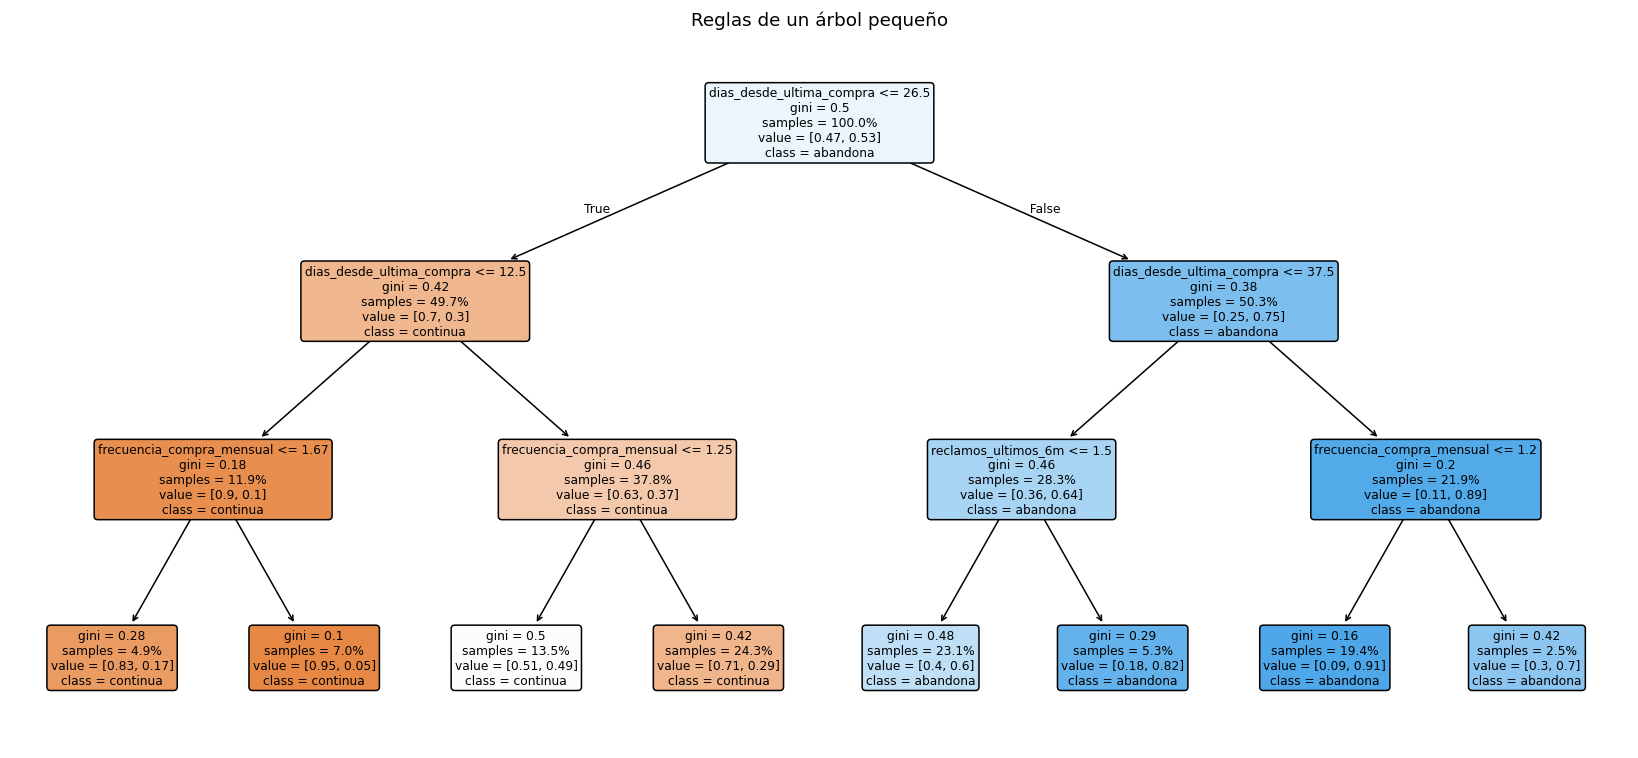

In [8]:
variables_arbol = [
    "dias_desde_ultima_compra",
    "frecuencia_compra_mensual",
    "reclamos_ultimos_6m",
    "antiguedad_meses",
]

arbol_pequeno = DecisionTreeClassifier(
    max_depth=3,
    min_samples_leaf=18,
    random_state=28,
)
arbol_pequeno.fit(X_train[variables_arbol], y_train)

fig, ax = plt.subplots(figsize=(15, 7))
plot_tree(
    arbol_pequeno,
    feature_names=variables_arbol,
    class_names=["continua", "abandona"],
    filled=True,
    rounded=True,
    proportion=True,
    precision=2,
    fontsize=8,
    ax=ax,
)
ax.set_title("Reglas de un árbol pequeño")
plt.tight_layout()
plt.show()


Cada camino constituye una explicación legible del árbol pequeño. Esa claridad disminuye si el árbol crece demasiado y deja de ser práctica cuando un bosque combina cientos de árboles.

Transparencia no significa corrección ni causalidad. El árbol muestra las reglas que aprendió, no las causas reales del abandono.


## 6. Interpretar coeficientes de la regresión logística

Recuperaremos los nombres de las columnas que llegan al modelo después del preprocesamiento. Como las variables numéricas fueron estandarizadas, sus coeficientes representan cambios asociados a una desviación estándar, no a una unidad original.

El signo positivo empuja la puntuación hacia `abandono = 1`; el signo negativo la aleja. En el plan, `Basico` es la categoría omitida por `drop="first"` y funciona como referencia.


In [9]:
logistica_ajustada = modelos["Regresion logistica"]
nombres_transformados = (
    logistica_ajustada
    .named_steps["preprocesamiento"]
    .get_feature_names_out()
)
coeficientes = logistica_ajustada.named_steps["modelo"].coef_[0]

tabla_coeficientes = (
    pd.DataFrame({
        "variable_transformada": nombres_transformados,
        "coeficiente": coeficientes,
        "odds_ratio": np.exp(coeficientes),
        "magnitud_absoluta": np.abs(coeficientes),
    })
    .sort_values("coeficiente")
    .reset_index(drop=True)
)
tabla_coeficientes


,variable_transformada,coeficiente,odds_ratio,magnitud_absoluta
0,cat__plan_Premium,-0.597,0.550,0.597
1,num__gasto_mensual,-0.466,0.627,0.466
2,num__frecuencia_compra_mensual,-0.438,0.645,0.438
3,num__antiguedad_meses,-0.262,0.770,0.262
4,cat__plan_Plus,-0.153,0.858,0.153
5,num__ruido_aleatorio,0.028,1.028,0.028
6,num__compras_ultimos_6m,0.192,1.212,0.192
7,num__reclamos_ultimos_6m,0.498,1.645,0.498
8,num__dias_desde_ultima_compra,1.036,2.817,1.036


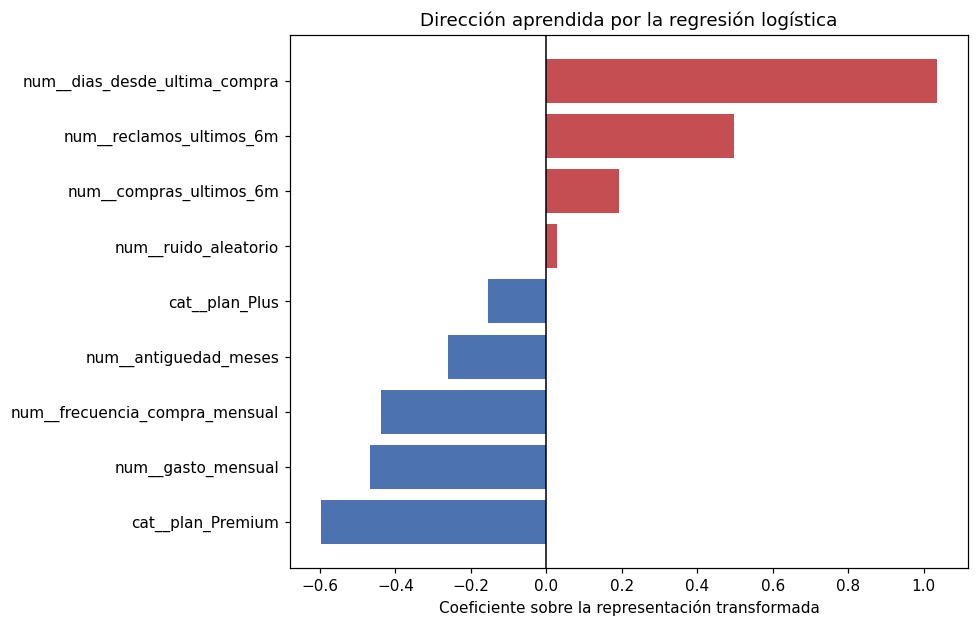

In [10]:
fig, ax = plt.subplots(figsize=(9, 5.8))
colores = np.where(
    tabla_coeficientes["coeficiente"] >= 0,
    "#C44E52",
    "#4C72B0",
)

ax.barh(
    tabla_coeficientes["variable_transformada"],
    tabla_coeficientes["coeficiente"],
    color=colores,
)
ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("Coeficiente sobre la representación transformada")
ax.set_ylabel("")
ax.set_title("Dirección aprendida por la regresión logística")
plt.tight_layout()
plt.show()


Los coeficientes describen asociaciones condicionadas a las demás variables del modelo. No dicen que aumentar deliberadamente una variable vaya a causar un cambio en el abandono.

El `odds_ratio` ayuda a leer la puntuación logística, pero tampoco es un cambio directo en probabilidad. La misma modificación puede alterar la probabilidad de manera diferente según el punto de partida.

La mayor asociación positiva corresponde a `dias_desde_ultima_compra`, con un coeficiente estandarizado cercano a **1,036**. Los reclamos también empujan hacia el abandono. `plan_Premium`, gasto, frecuencia y antigüedad lo hacen en sentido contrario. `ruido_aleatorio` queda muy próximo a cero, como esperamos de una columna sin señal real.


## 7. Comprobar por qué la escala cambia la lectura

Entrenaremos dos regresiones logísticas únicamente con variables numéricas: una con unidades originales y otra con estandarización. Ambas pueden producir predicciones semejantes, pero la magnitud de sus coeficientes no se compara de la misma manera.


In [11]:
logistica_sin_escala = LogisticRegression(max_iter=2_000, random_state=28)
logistica_con_escala = Pipeline([
    ("escala", StandardScaler()),
    ("modelo", LogisticRegression(max_iter=2_000, random_state=28)),
])

logistica_sin_escala.fit(X_train[variables_numericas], y_train)
logistica_con_escala.fit(X_train[variables_numericas], y_train)

tabla_escala = pd.DataFrame({
    "variable": variables_numericas,
    "coeficiente_unidades_originales":
        logistica_sin_escala.coef_[0],
    "coeficiente_estandarizado":
        logistica_con_escala.named_steps["modelo"].coef_[0],
})
tabla_escala["orden_original"] = (
    tabla_escala["coeficiente_unidades_originales"].abs()
    .rank(ascending=False, method="min")
    .astype(int)
)
tabla_escala["orden_estandarizado"] = (
    tabla_escala["coeficiente_estandarizado"].abs()
    .rank(ascending=False, method="min")
    .astype(int)
)
tabla_escala.sort_values("orden_estandarizado")


,variable,coeficiente_unidades_originales,coeficiente_estandarizado,orden_original,orden_estandarizado
0,dias_desde_ultima_compra,0.082,1.043,3,1
3,reclamos_ultimos_6m,0.499,0.487,2,2
2,frecuencia_compra_mensual,-0.782,-0.457,1,3
5,gasto_mensual,-0.028,-0.443,6,4
4,antiguedad_meses,-0.011,-0.255,7,5
1,compras_ultimos_6m,0.062,0.216,4,6
6,ruido_aleatorio,0.031,0.030,5,7


Un coeficiente pequeño puede corresponder a una variable cuyos valores recorren decenas de unidades. Comparar magnitudes sin considerar la escala puede producir un ranking engañoso.

Estandarizar facilita una comparación aproximada entre variables numéricas, aunque no elimina otros problemas como correlación, regularización o relaciones no lineales.


## 8. Observar el efecto de variables correlacionadas

`compras_ultimos_6m` y `frecuencia_compra_mensual` describen aspectos muy próximos. Primero mediremos su correlación y luego quitaremos una de ellas para observar cómo cambia el coeficiente de la otra.


In [12]:
correlacion_compras = (
    X_train[
        ["compras_ultimos_6m", "frecuencia_compra_mensual"]
    ]
    .corr()
    .iloc[0, 1]
)

variables_sin_compras = [
    variable
    for variable in variables_numericas
    if variable != "compras_ultimos_6m"
]

modelo_numerico_completo = Pipeline([
    ("escala", StandardScaler()),
    ("modelo", LogisticRegression(max_iter=2_000, random_state=28)),
])
modelo_numerico_reducido = clone(modelo_numerico_completo)

modelo_numerico_completo.fit(
    X_train[variables_numericas],
    y_train,
)
modelo_numerico_reducido.fit(
    X_train[variables_sin_compras],
    y_train,
)

coef_completo = dict(zip(
    variables_numericas,
    modelo_numerico_completo.named_steps["modelo"].coef_[0],
))
coef_reducido = dict(zip(
    variables_sin_compras,
    modelo_numerico_reducido.named_steps["modelo"].coef_[0],
))

print(f"Correlación entre las dos variables: {correlacion_compras:.3f}")
pd.DataFrame({
    "modelo": [
        "incluye ambas variables",
        "quita compras_ultimos_6m",
    ],
    "coef_frecuencia_compra_mensual": [
        coef_completo["frecuencia_compra_mensual"],
        coef_reducido["frecuencia_compra_mensual"],
    ],
})


Correlación entre las dos variables: 0.943


,modelo,coef_frecuencia_compra_mensual
0,incluye ambas variables,-0.457
1,quita compras_ultimos_6m,-0.284


El coeficiente no es una propiedad fija de la columna. Depende de qué otras variables están disponibles. Cuando dos columnas comparten señal, el modelo puede repartir o desplazar sus pesos.

Esto tampoco vuelve inútiles a los coeficientes: indica que deben interpretarse como partes de un modelo específico, no como efectos absolutos.


## 9. Comparar importancia interna e importancia por permutación

Random Forest ofrece `feature_importances_`, una medida interna basada en las mejoras obtenidas en sus divisiones. Como el plan se convirtió en dos columnas, sumaremos sus importancias para volver a la variable original.

Luego calcularemos `permutation_importance` sobre validación. Esta técnica desordena una columna original y mide cuánto cae el F1. Por eso evalúa el pipeline completo y conserva una fila por variable de entrada.


In [13]:
bosque_ajustado = modelos["Random Forest"]
nombres_bosque = (
    bosque_ajustado
    .named_steps["preprocesamiento"]
    .get_feature_names_out()
)
importancias_internas = (
    bosque_ajustado
    .named_steps["modelo"]
    .feature_importances_
)

def variable_original(nombre_transformado):
    if nombre_transformado.startswith("num__"):
        return nombre_transformado.replace("num__", "", 1)
    if nombre_transformado.startswith("cat__plan_"):
        return "plan"
    return nombre_transformado

tabla_interna = pd.DataFrame({
    "variable_transformada": nombres_bosque,
    "variable_original": [
        variable_original(nombre)
        for nombre in nombres_bosque
    ],
    "importancia_interna": importancias_internas,
})

importancia_interna_agrupada = (
    tabla_interna
    .groupby("variable_original", as_index=False)["importancia_interna"]
    .sum()
)
importancia_interna_agrupada.sort_values(
    "importancia_interna",
    ascending=False,
)


,variable_original,importancia_interna
2,dias_desde_ultima_compra,0.289
4,gasto_mensual,0.221
3,frecuencia_compra_mensual,0.156
0,antiguedad_meses,0.089
1,compras_ultimos_6m,0.085
7,ruido_aleatorio,0.085
6,reclamos_ultimos_6m,0.054
5,plan,0.021


In [14]:
permutacion_f1 = permutation_importance(
    bosque_ajustado,
    X_validacion,
    y_validacion,
    scoring="f1",
    n_repeats=30,
    random_state=28,
    n_jobs=-1,
)

tabla_permutacion_f1 = pd.DataFrame({
    "variable_original": X_validacion.columns,
    "permutacion_f1_media": permutacion_f1.importances_mean,
    "permutacion_f1_desviacion": permutacion_f1.importances_std,
})

comparacion_importancias = (
    importancia_interna_agrupada
    .merge(tabla_permutacion_f1, on="variable_original")
    .sort_values("permutacion_f1_media", ascending=True)
)
comparacion_importancias


,variable_original,importancia_interna,permutacion_f1_media,permutacion_f1_desviacion
3,frecuencia_compra_mensual,0.156,-0.008,0.013
1,compras_ultimos_6m,0.085,-0.007,0.007
7,ruido_aleatorio,0.085,-0.005,0.008
0,antiguedad_meses,0.089,-0.004,0.009
5,plan,0.021,0.002,0.005
6,reclamos_ultimos_6m,0.054,0.012,0.009
4,gasto_mensual,0.221,0.023,0.012
2,dias_desde_ultima_compra,0.289,0.046,0.017


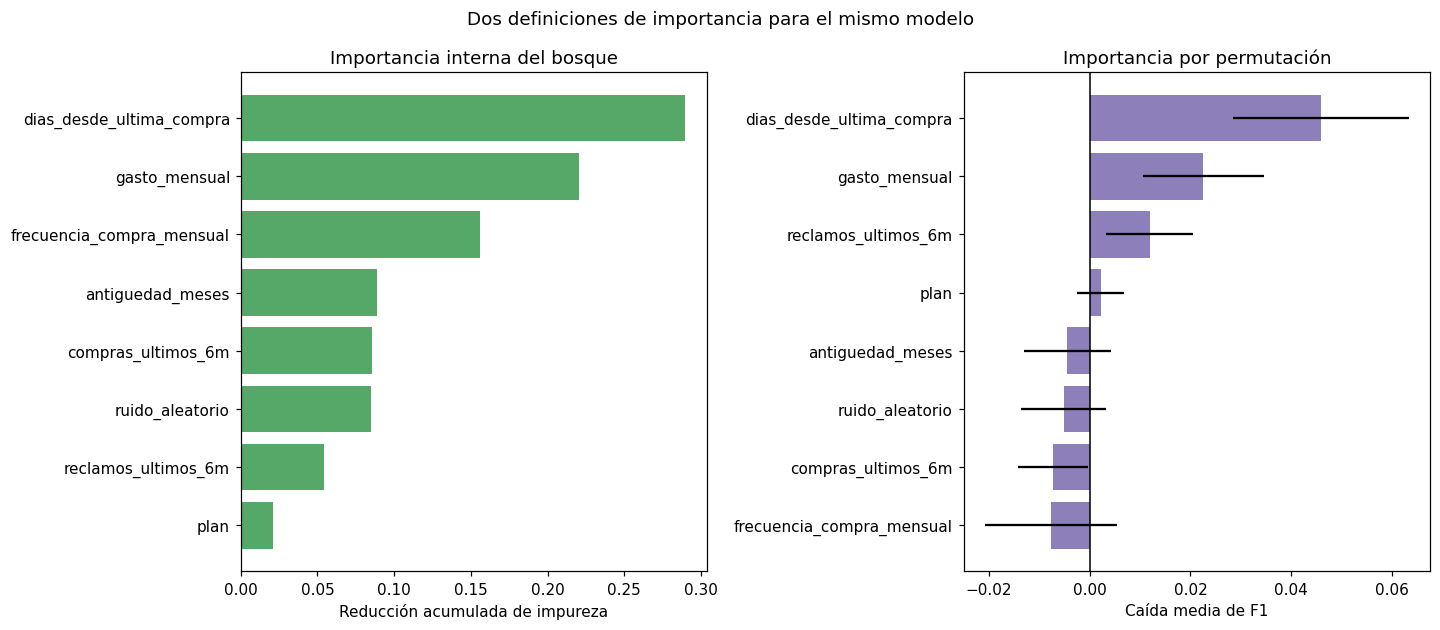

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13.2, 5.8))

orden_interno = comparacion_importancias.sort_values(
    "importancia_interna",
    ascending=True,
)
axes[0].barh(
    orden_interno["variable_original"],
    orden_interno["importancia_interna"],
    color="#55A868",
)
axes[0].set_title("Importancia interna del bosque")
axes[0].set_xlabel("Reducción acumulada de impureza")
axes[0].set_ylabel("")

axes[1].barh(
    comparacion_importancias["variable_original"],
    comparacion_importancias["permutacion_f1_media"],
    xerr=comparacion_importancias["permutacion_f1_desviacion"],
    color="#8172B3",
    alpha=0.9,
)
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set_title("Importancia por permutación")
axes[1].set_xlabel("Caída media de F1")
axes[1].set_ylabel("")

fig.suptitle("Dos definiciones de importancia para el mismo modelo")
plt.tight_layout()
plt.show()


Los paneles no tienen la misma unidad ni deben compararse barra por barra como si fueran una única escala. La importancia interna describe cuánto usó el bosque una variable para dividir sus datos de entrenamiento. La permutación pregunta cuánto necesita esa columna para sostener el F1 en validación.

Una importancia de permutación cercana a cero no demuestra que la variable carezca de relación con `y`. Puede contener señal redundante con otra columna, no ser usada por este modelo o mostrar una estimación inestable.

La diferencia resulta visible con `ruido_aleatorio`: recibe aproximadamente **0,085** de importancia interna, pero al permutarla el F1 no cae. En cambio, `dias_desde_ultima_compra` presenta la mayor caída media, cercana a **0,046**. La comparación ayuda a no convertir una única definición de importancia en un ranking definitivo.


## 10. Comprobar que la importancia depende de la métrica

Repetiremos la permutación usando recall. La pregunta cambia: ya no medimos cuánto sostiene cada variable el equilibrio resumido por F1, sino cuánto sostiene la detección de clientes que abandonan.


In [16]:
permutacion_recall = permutation_importance(
    bosque_ajustado,
    X_validacion,
    y_validacion,
    scoring="recall",
    n_repeats=30,
    random_state=28,
    n_jobs=-1,
)

tabla_metricas = pd.DataFrame({
    "variable": X_validacion.columns,
    "importancia_F1": permutacion_f1.importances_mean,
    "desviacion_F1": permutacion_f1.importances_std,
    "importancia_recall": permutacion_recall.importances_mean,
    "desviacion_recall": permutacion_recall.importances_std,
})
tabla_metricas["diferencia_absoluta"] = (
    tabla_metricas["importancia_F1"]
    - tabla_metricas["importancia_recall"]
).abs()
tabla_metricas.sort_values(
    "diferencia_absoluta",
    ascending=False,
)


,variable,importancia_F1,desviacion_F1,importancia_recall,desviacion_recall,diferencia_absoluta
5,gasto_mensual,0.023,0.012,0.006,0.015,0.017
2,frecuencia_compra_mensual,-0.008,0.013,-0.024,0.015,0.016
1,compras_ultimos_6m,-0.007,0.007,-0.016,0.009,0.009
4,antiguedad_meses,-0.004,0.009,-0.013,0.013,0.008
7,ruido_aleatorio,-0.005,0.008,-0.011,0.011,0.006
3,reclamos_ultimos_6m,0.012,0.009,0.007,0.012,0.005
0,dias_desde_ultima_compra,0.046,0.017,0.047,0.019,0.001
6,plan,0.002,0.005,0.002,0.008,0.000


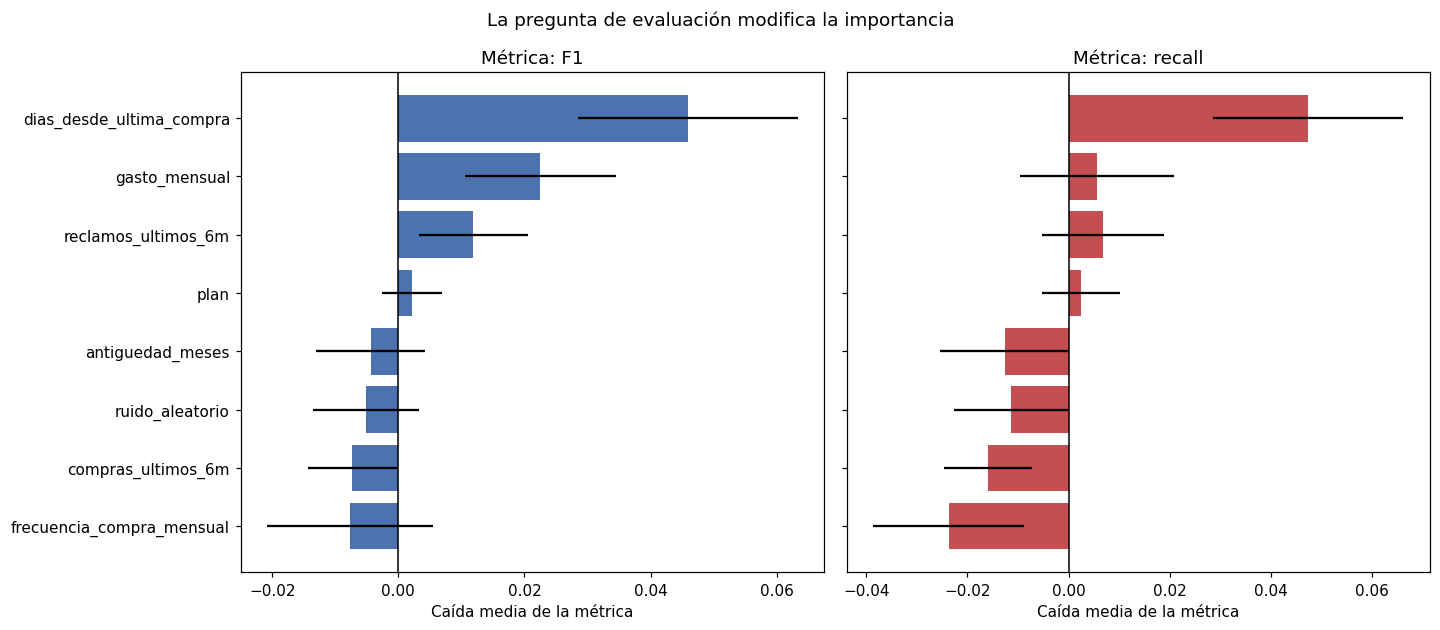

In [17]:
orden = (
    tabla_metricas
    .sort_values("importancia_F1", ascending=True)
    ["variable"]
)
tabla_plot = tabla_metricas.set_index("variable").loc[orden]

fig, axes = plt.subplots(1, 2, figsize=(13.2, 5.8), sharey=True)
axes[0].barh(
    tabla_plot.index,
    tabla_plot["importancia_F1"],
    xerr=tabla_plot["desviacion_F1"],
    color="#4C72B0",
)
axes[0].axvline(0, color="black", linewidth=1)
axes[0].set_title("Métrica: F1")
axes[0].set_xlabel("Caída media de la métrica")

axes[1].barh(
    tabla_plot.index,
    tabla_plot["importancia_recall"],
    xerr=tabla_plot["desviacion_recall"],
    color="#C44E52",
)
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set_title("Métrica: recall")
axes[1].set_xlabel("Caída media de la métrica")

fig.suptitle("La pregunta de evaluación modifica la importancia")
plt.tight_layout()
plt.show()


La permutation importance no calcula una relevancia universal. Mide el deterioro de una métrica concreta en un conjunto concreto.

Las barras de error representan la variabilidad entre permutaciones. Si dos valores son próximos y variables, no conviene convertir pequeñas diferencias de orden en conclusiones fuertes.


## 11. Pasar de una explicación global a una local

Los coeficientes anteriores describen el modelo lineal en conjunto. Para explicar una predicción individual multiplicaremos cada valor transformado por su coeficiente.

La suma de esos aportes y del intercepto reproduce exactamente el `logit`. Al aplicar la función sigmoide recuperamos la probabilidad calculada por la regresión logística.


In [18]:
probabilidades_validacion = logistica_ajustada.predict_proba(
    X_validacion
)[:, 1]
predicciones_validacion = (
    probabilidades_validacion >= 0.5
).astype(int)

candidatos = pd.DataFrame({
    "indice": X_validacion.index,
    "real": y_validacion.to_numpy(),
    "prediccion": predicciones_validacion,
    "probabilidad_abandono": probabilidades_validacion,
})

verdaderos_positivos = candidatos.query(
    "real == 1 and prediccion == 1"
)
if len(verdaderos_positivos) > 0:
    indice_caso = int(
        verdaderos_positivos
        .sort_values("probabilidad_abandono", ascending=False)
        .iloc[0]["indice"]
    )
else:
    indice_caso = int(
        candidatos
        .sort_values("probabilidad_abandono", ascending=False)
        .iloc[0]["indice"]
    )

caso = X_validacion.loc[[indice_caso]]
caso.assign(
    abandono_real=int(y_validacion.loc[indice_caso]),
    probabilidad_predicha=float(
        logistica_ajustada.predict_proba(caso)[0, 1]
    ),
)


,dias_desde_ultima_compra,compras_ultimos_6m,frecuencia_compra_mensual,reclamos_ultimos_6m,antiguedad_meses,gasto_mensual,plan,ruido_aleatorio,abandono_real,probabilidad_predicha
111,52,0,0.000,4,28,8.000,Basico,0.258,1,0.997


In [19]:
caso_transformado = (
    logistica_ajustada
    .named_steps["preprocesamiento"]
    .transform(caso)
)[0]

aportes = caso_transformado * coeficientes
intercepto = logistica_ajustada.named_steps["modelo"].intercept_[0]
logit_reconstruido = intercepto + aportes.sum()
probabilidad_reconstruida = 1 / (1 + np.exp(-logit_reconstruido))

tabla_aportes = (
    pd.DataFrame({
        "variable_transformada": nombres_transformados,
        "valor_transformado": caso_transformado,
        "coeficiente": coeficientes,
        "aporte_al_logit": aportes,
        "magnitud_absoluta": np.abs(aportes),
    })
    .sort_values("magnitud_absoluta", ascending=False)
    .reset_index(drop=True)
)

print(f"Intercepto: {intercepto:.4f}")
print(f"Logit reconstruido: {logit_reconstruido:.4f}")
print(f"Probabilidad reconstruida: {probabilidad_reconstruida:.4f}")
print(
    "Probabilidad de predict_proba:",
    f"{logistica_ajustada.predict_proba(caso)[0, 1]:.4f}",
)
tabla_aportes


Intercepto: 0.3334
Logit reconstruido: 5.7970
Probabilidad reconstruida: 0.9970
Probabilidad de predict_proba: 0.9970


,variable_transformada,valor_transformado,coeficiente,aporte_al_logit,magnitud_absoluta
0,num__dias_desde_ultima_compra,1.924,1.036,1.993,1.993
1,num__reclamos_ultimos_6m,3.269,0.498,1.627,1.627
2,num__gasto_mensual,-2.527,-0.466,1.178,1.178
3,num__frecuencia_compra_mensual,-2.223,-0.438,0.974,0.974
4,num__compras_ultimos_6m,-2.320,0.192,-0.446,0.446
5,num__antiguedad_meses,-0.493,-0.262,0.129,0.129
6,num__ruido_aleatorio,0.315,0.028,0.009,0.009
7,cat__plan_Plus,0.000,-0.153,-0.000,0.000
8,cat__plan_Premium,0.000,-0.597,-0.000,0.000


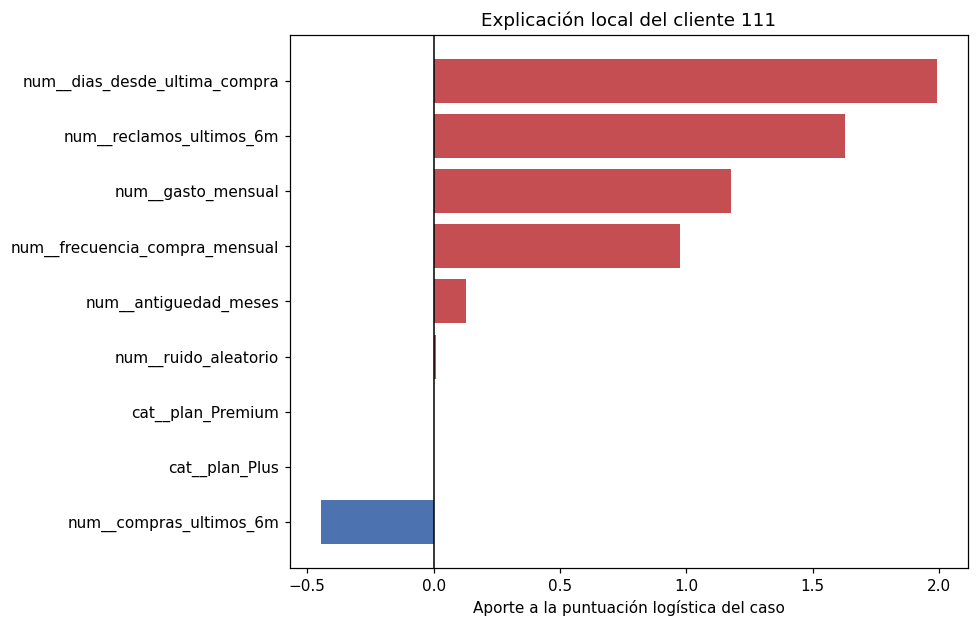

In [20]:
tabla_aportes_plot = tabla_aportes.sort_values(
    "aporte_al_logit"
)
colores_aportes = np.where(
    tabla_aportes_plot["aporte_al_logit"] >= 0,
    "#C44E52",
    "#4C72B0",
)

fig, ax = plt.subplots(figsize=(9, 5.8))
ax.barh(
    tabla_aportes_plot["variable_transformada"],
    tabla_aportes_plot["aporte_al_logit"],
    color=colores_aportes,
)
ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("Aporte a la puntuación logística del caso")
ax.set_ylabel("")
ax.set_title(
    f"Explicación local del cliente {indice_caso}"
)
plt.tight_layout()
plt.show()


Una barra positiva aumenta la puntuación de abandono para este cliente; una negativa la reduce. Una variable con un coeficiente global grande puede aportar poco en un caso si su valor transformado está cerca de cero.

Esta explicación es exacta para la parte lineal de esta regresión logística. Sigue explicando **al modelo**, no las causas reales del comportamiento del cliente. Tampoco puede trasladarse sin más a Random Forest.

Para el caso seleccionado, la suma reconstruye un `logit` de **5,7970** y una probabilidad de **0,9970**, idéntica a `predict_proba`. Los días sin comprar y los reclamos son los aportes positivos principales de ese cliente concreto.


## 12. Revisar distintos tipos de casos

Una explicación local aislada puede resultar convincente y aun así ofrecer una visión incompleta. Revisaremos un verdadero positivo, un falso positivo y un falso negativo cuando estén disponibles.

La tabla mostrará qué dos variables transformadas empujaron más hacia el abandono y cuáles dos lo hicieron con más fuerza hacia la continuidad.


In [21]:
def seleccionar_caso(real, prediccion, ordenar_ascendente=False):
    subconjunto = candidatos.query(
        "real == @real and prediccion == @prediccion"
    )
    if subconjunto.empty:
        return None
    return int(
        subconjunto
        .sort_values(
            "probabilidad_abandono",
            ascending=ordenar_ascendente,
        )
        .iloc[0]["indice"]
    )

indices_revision = {
    "verdadero_positivo": seleccionar_caso(1, 1),
    "falso_positivo": seleccionar_caso(0, 1),
    "falso_negativo": seleccionar_caso(1, 0, ordenar_ascendente=True),
}

filas_casos = []
for tipo, indice in indices_revision.items():
    if indice is None:
        continue
    fila = X_validacion.loc[[indice]]
    transformada = (
        logistica_ajustada
        .named_steps["preprocesamiento"]
        .transform(fila)
    )[0]
    aportes_fila = pd.Series(
        transformada * coeficientes,
        index=nombres_transformados,
    )
    mas_positivos = aportes_fila.nlargest(2)
    mas_negativos = aportes_fila.nsmallest(2)
    filas_casos.append({
        "tipo": tipo,
        "indice": indice,
        "probabilidad": logistica_ajustada.predict_proba(fila)[0, 1],
        "empuja_hacia_abandono": "; ".join(
            f"{nombre} ({valor:+.2f})"
            for nombre, valor in mas_positivos.items()
        ),
        "empuja_hacia_continuidad": "; ".join(
            f"{nombre} ({valor:+.2f})"
            for nombre, valor in mas_negativos.items()
        ),
    })

pd.DataFrame(filas_casos).set_index("tipo")


,indice,probabilidad,empuja_hacia_abandono,empuja_hacia_continuidad
tipo,,,,
verdadero_positivo,111,0.997,num__dias_desde_ultima_compra (+1.99); num__re...,num__compras_ultimos_6m (-0.45); cat__plan_Plu...
falso_positivo,410,0.953,num__gasto_mensual (+0.94); num__dias_desde_ul...,num__compras_ultimos_6m (-0.26); cat__plan_Plu...
falso_negativo,1061,0.096,num__compras_ultimos_6m (+0.12); num__reclamos...,num__dias_desde_ultima_compra (-1.87); num__ga...


Revisar aciertos y errores conecta la interpretación con el uso real. Un ranking global no muestra por sí solo qué combinaciones confunden al modelo ni qué casos quedan cerca del umbral.

Si una categoría no aparece en la tabla, significa que ese tipo de resultado no ocurrió en esta validación; no que sea imposible.


## 13. Usar la interpretación para descubrir fuga de datos

Crearemos deliberadamente una variable problemática: `baja_confirmada`, registrada después de que el cliente abandonó. La columna será casi una copia de `y`, con unos pocos errores administrativos.

En un proyecto real no estaría disponible al momento de predecir. La comparación muestra cómo una métrica excelente puede esconder un flujo inválido.


In [22]:
generador_fuga = np.random.default_rng(280)
X_con_fuga = X.copy()
X_con_fuga["baja_confirmada"] = y.to_numpy()

indices_ruido = generador_fuga.choice(
    X_con_fuga.index,
    size=int(0.03 * len(X_con_fuga)),
    replace=False,
)
X_con_fuga.loc[indices_ruido, "baja_confirmada"] = (
    1 - X_con_fuga.loc[indices_ruido, "baja_confirmada"]
)

Xf_desarrollo = X_con_fuga.loc[X_desarrollo.index]
Xf_test = X_con_fuga.loc[X_test.index]
Xf_train = X_con_fuga.loc[X_train.index]
Xf_validacion = X_con_fuga.loc[X_validacion.index]

preprocesador_fuga = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            variables_numericas + ["baja_confirmada"],
        ),
        (
            "cat",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore",
                sparse_output=False,
            ),
            variables_categoricas,
        ),
    ],
)

modelo_con_fuga = Pipeline([
    ("preprocesamiento", preprocesador_fuga),
    (
        "modelo",
        RandomForestClassifier(
            n_estimators=300,
            min_samples_leaf=5,
            random_state=28,
            n_jobs=-1,
        ),
    ),
])
modelo_con_fuga.fit(Xf_train, y_train)

pred_sin_fuga = bosque_ajustado.predict(X_validacion)
pred_con_fuga = modelo_con_fuga.predict(Xf_validacion)

pd.DataFrame({
    "modelo": ["sin fuga", "con baja_confirmada"],
    "accuracy_validacion": [
        accuracy_score(y_validacion, pred_sin_fuga),
        accuracy_score(y_validacion, pred_con_fuga),
    ],
    "recall_validacion": [
        recall_score(y_validacion, pred_sin_fuga),
        recall_score(y_validacion, pred_con_fuga),
    ],
    "f1_validacion": [
        f1_score(y_validacion, pred_sin_fuga),
        f1_score(y_validacion, pred_con_fuga),
    ],
}).set_index("modelo")


,accuracy_validacion,recall_validacion,f1_validacion
modelo,,,
sin fuga,0.742,0.774,0.760
con baja_confirmada,0.969,0.984,0.971


In [23]:
permutacion_fuga = permutation_importance(
    modelo_con_fuga,
    Xf_validacion,
    y_validacion,
    scoring="f1",
    n_repeats=20,
    random_state=28,
    n_jobs=-1,
)

tabla_fuga = (
    pd.DataFrame({
        "variable": Xf_validacion.columns,
        "importancia_f1": permutacion_fuga.importances_mean,
        "desviacion": permutacion_fuga.importances_std,
    })
    .sort_values("importancia_f1", ascending=False)
)
tabla_fuga


,variable,importancia_f1,desviacion
8,baja_confirmada,0.434,0.026
0,dias_desde_ultima_compra,0.000,0.001
1,compras_ultimos_6m,0.000,0.000
3,reclamos_ultimos_6m,0.000,0.000
2,frecuencia_compra_mensual,0.000,0.000
4,antiguedad_meses,0.000,0.000
5,gasto_mensual,0.000,0.000
6,plan,0.000,0.000
7,ruido_aleatorio,0.000,0.000


La importancia dominante de `baja_confirmada` no convierte esa columna en una buena variable. Revela que el modelo depende de información posterior al evento.

Interpretar permite detectar la señal sospechosa, pero la herramienta no conoce la cronología. Decidir que existe fuga requiere comprender cuándo y cómo se genera cada dato.

La fuga eleva el F1 de validación de **0,760** a **0,971**. Al permutar `baja_confirmada`, el F1 cae aproximadamente **0,434**; las demás columnas quedan cerca de cero porque el modelo ya dispone de una copia casi directa del resultado.


## 14. Evaluar una vez sobre el test reservado

Para cerrar el ejemplo elegiremos la regresión logística si su F1 de validación queda a menos de 0,02 del bosque. Este criterio didáctico representa una decisión posible: aceptar una diferencia pequeña a cambio de mayor transparencia directa.

Si la diferencia es mayor, elegiremos Random Forest. Después ajustaremos el modelo elegido con todo desarrollo y consultaremos el test una sola vez.


In [24]:
f1_logistica_validacion = comparacion_validacion.loc[
    "Regresion logistica",
    "f1_validacion",
]
f1_bosque_validacion = comparacion_validacion.loc[
    "Random Forest",
    "f1_validacion",
]

if f1_bosque_validacion - f1_logistica_validacion < 0.02:
    nombre_elegido = "Regresion logistica"
else:
    nombre_elegido = "Random Forest"

modelo_final = clone(modelos[nombre_elegido])
modelo_final.fit(X_desarrollo, y_desarrollo)
prediccion_test = modelo_final.predict(X_test)

matriz_test = confusion_matrix(y_test, prediccion_test)

print("Modelo elegido:", nombre_elegido)
print(f"Accuracy test: {accuracy_score(y_test, prediccion_test):.3f}")
print(f"Recall test: {recall_score(y_test, prediccion_test):.3f}")
print(f"F1 test: {f1_score(y_test, prediccion_test):.3f}")
print("\nMatriz de confusión [[TN, FP], [FN, TP]]:")
matriz_test


Modelo elegido: Regresion logistica
Accuracy test: 0.764
Recall test: 0.810
F1 test: 0.783

Matriz de confusión [[TN, FP], [FN, TP]]:


array([[122,  49],
       [ 36, 153]])

El criterio de elección se declaró antes de mirar el test. El resultado final describe este conjunto sintético y este flujo; no demuestra que el mismo modelo sea preferible en otros problemas.

Interpretar no reemplaza la evaluación. Del mismo modo, una buena evaluación no reemplaza la revisión de las señales utilizadas.

El criterio elige la regresión logística. En el test reservado alcanza accuracy **0,764**, recall **0,810** y F1 **0,783**. La matriz contiene 49 falsos positivos y 36 falsos negativos: incluso un modelo interpretable y razonablemente útil conserva errores que deben comunicarse.


## 15. Actividad modificable

El siguiente bloque permite cambiar la métrica y la cantidad de repeticiones de `permutation_importance`. Probá con `"accuracy"`, `"f1"` o `"recall"` y con 5, 15 o 40 repeticiones.

Observá qué variables mantienen una señal clara, cuáles cambian de orden y cómo se modifica la variabilidad.


In [25]:
metrica_actividad = "recall"
repeticiones_actividad = 15

resultado_actividad = permutation_importance(
    bosque_ajustado,
    X_validacion,
    y_validacion,
    scoring=metrica_actividad,
    n_repeats=repeticiones_actividad,
    random_state=28,
    n_jobs=-1,
)

(
    pd.DataFrame({
        "variable": X_validacion.columns,
        "importancia_media": resultado_actividad.importances_mean,
        "desviacion": resultado_actividad.importances_std,
    })
    .sort_values("importancia_media", ascending=False)
    .reset_index(drop=True)
)


,variable,importancia_media,desviacion
0,dias_desde_ultima_compra,0.052,0.012
1,reclamos_ultimos_6m,0.008,0.012
2,gasto_mensual,0.005,0.017
3,plan,0.004,0.009
4,ruido_aleatorio,-0.010,0.013
5,compras_ultimos_6m,-0.012,0.007
6,antiguedad_meses,-0.015,0.013
7,frecuencia_compra_mensual,-0.023,0.014


Con pocas repeticiones, una permutación afortunada o desfavorable puede cambiar más el resultado. Aumentarlas suele estabilizar la estimación, pero también aumenta el tiempo de cálculo.

Una importancia negativa pequeña no significa que una variable “proteja” al modelo. Puede aparecer por azar o por inestabilidad cuando permutarla produce una métrica apenas mejor.


## 16. Una guía para comunicar interpretaciones

Antes de presentar una explicación conviene responder:

1. **¿Qué se interpreta?** Un modelo, una métrica y una representación concreta.
2. **¿Sobre qué datos?** Entrenamiento, validación o test no responden la misma pregunta.
3. **¿La lectura es global o local?** Un patrón promedio no explica todos los casos.
4. **¿Qué efecto tuvo el preprocesamiento?** Escalado y codificación cambian las columnas que recibe el modelo.
5. **¿Hay variables correlacionadas?** La señal puede repartirse o reemplazarse.
6. **¿La variable estaba disponible al predecir?** Una importancia alta puede revelar fuga.
7. **¿El lenguaje distingue asociación de causalidad?** “El modelo se apoya en” suele ser más correcto que “esta variable causa”.

La interpretación adecuada también depende del público. Un equipo técnico puede necesitar coeficientes y desviaciones; una persona usuaria necesita una explicación clara del caso y de sus límites.


## 17. Síntesis

En este cuaderno:

- retomamos el ejemplo teórico de abandono de clientes;
- comparamos una regresión logística, un árbol pequeño y Random Forest;
- interpretamos coeficientes sobre variables transformadas;
- comprobamos por qué escala y correlación modifican su lectura;
- diferenciamos importancia interna e importancia por permutación;
- observamos que la métrica elegida cambia la importancia;
- reconstruimos una predicción local de la regresión logística;
- revisamos aciertos y errores individuales;
- detectamos una fuga mediante una variable posterior al abandono;
- reservamos el test hasta la decisión final;
- separamos interpretación predictiva de explicación causal.

Interpretar un modelo no consiste en inventarle una historia convincente. Consiste en reunir evidencia sobre su comportamiento, contrastarla con el contexto y comunicarla con límites claros.


## Para pensar

1. ¿Por qué el coeficiente de una variable puede cambiar cuando agregamos o quitamos otra variable correlacionada?
2. ¿Qué pregunta responde `feature_importances_` y qué pregunta diferente responde `permutation_importance`?
3. ¿Por qué una variable puede ser importante para recall y menos importante para F1?
4. ¿Qué diferencia existe entre explicar globalmente un modelo y reconstruir los aportes de una predicción individual?
5. ¿Por qué la alta importancia de `baja_confirmada` constituye una advertencia y no una razón para conservarla?
